In [64]:
import random
import matplotlib.pyplot as plt
import numpy as np
from treasure_env import MultiTreasureHunterMDP,  LEFT, RIGHT, UP, DOWN, ACTIONS

# Środowisko

In [65]:
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

class MultiTreasureHunterMDP:
    def __init__(self, map_lines):
        self.original_map = [list(row) for row in map_lines]
        self.height = len(self.original_map)
        self.width = len(self.original_map[0])
        self.treasures = set()
        self.bases = {}
        self.agent_pos = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}
        self.winning_score = len([tile for row in self.original_map for tile in row if tile == 'T']) // 2 + 1

    def reset(self):
        self.map = [row[:] for row in self.original_map]
        self.treasures = set()
        self.bases = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}

        for y in range(self.height):
            for x in range(self.width):
                tile = self.map[y][x]
                if tile == 'T':
                    self.treasures.add((x, y))
                elif tile == 'A':
                    self.bases['1'] = (x, y)
                    self.map[y][x] = '.'
                elif tile == 'B':
                    self.bases['2'] = (x, y)
                    self.map[y][x] = '.'

        self.agent_pos['1'] = self.bases['1']
        self.agent_pos['2'] = self.bases['2']

        return self._get_state()

    def _get_state(self):
        return (
            self.agent_pos['1'],
            self.agent_pos['2'],
            frozenset(self.treasures),
            self.agent_holding['1'],
            self.agent_holding['2']
        )

    def get_possible_actions(self, state=None, agent_id='1'):
        """Zwraca możliwe akcje dla konkretnego agenta"""
        if state is None:
            return [LEFT, DOWN, RIGHT, UP]
        
        pos1, pos2, _, _, _ = state
        agent_pos = pos1 if agent_id == '1' else pos2
        x, y = agent_pos
        
        possible_actions = []
        for action in [LEFT, DOWN, RIGHT, UP]:
            _x, _y = ACTIONS[action]
            new_x, new_y = x + _x, y + _y
            
            if 0 <= new_x < self.width and 0 <= new_y < self.height:
                if self.map[new_y][new_x] != '#':
                    possible_actions.append(action)
        
        return possible_actions

    def _move(self, agent_id, action):
        x, y = self.agent_pos[agent_id]
        _x, _y = ACTIONS[action]
        new_x, new_y = x + _x, y + _y

        if not (0 <= new_x < self.width and 0 <= new_y < self.height):
            return x, y
        if self.map[new_y][new_x] == '#':
            return x, y
        
        other_pos = self.agent_pos['2'] if agent_id == '1' else self.agent_pos['1']
        if (new_x, new_y) == other_pos:
            return x, y

        return new_x, new_y

    def step(self, action1, action2):
        rewards = {'1': 0.0, '2': 0.0}
        info = {}

        prev_pos1 = self.agent_pos['1']
        prev_pos2 = self.agent_pos['2']

        self.agent_pos['1'] = self._move('1', action1)
        self.agent_pos['2'] = self._move('2', action2)
        rewards['1'] -= 1
        rewards['2'] -= 1

        if self.agent_pos['1'] == self.agent_pos['2']:
            collision_pos = self.agent_pos['1']
            
            if self.agent_holding['1']:
                self.treasures.add(collision_pos)
                self.agent_holding['1'] = False
                info['1_drop_collision'] = True
            
            if self.agent_holding['2']:
                self.treasures.add(collision_pos)
                self.agent_holding['2'] = False
                info['2_drop_collision'] = True
            
            self.agent_pos['1'] = self.bases['1']
            self.agent_pos['2'] = self.bases['2']
            
            # rewards['1'] -= 10
            # rewards['2'] -= 10
            info['collision'] = True

        for agent_id, pos, prev_pos in [('1', self.agent_pos['1'], prev_pos1), ('2', self.agent_pos['2'], prev_pos2)]:
            x, y = pos

            if self.map[y][x] == 'H':
                if self.agent_holding[agent_id]:
                    self.treasures.add(prev_pos)
                    self.agent_holding[agent_id] = False
                    info[f'{agent_id}_drop_trap'] = True
                
                self.agent_pos[agent_id] = self.bases[agent_id]
                rewards[agent_id] = -30
                info[f'{agent_id}_trap'] = True
                continue

            if pos in self.treasures and not self.agent_holding[agent_id]:
                self.treasures.remove(pos)
                self.agent_holding[agent_id] = True
                rewards[agent_id] += 2
                info[f'{agent_id}_pick'] = True

            if pos == self.bases[agent_id] and self.agent_holding[agent_id]:
                self.agent_holding[agent_id] = False
                self.agent_score[agent_id] += 1  
                rewards[agent_id] += 5 
                info[f'{agent_id}_deposit'] = True

        done = self._is_done()
        return self._get_state(), rewards, done, info

    def _is_done(self):
        # check_trap1 = self.map[self.agent_pos['1'][1]][self.agent_pos['1'][0]] == 'H'
        # check_trap2 = self.map[self.agent_pos['2'][1]][self.agent_pos['2'][0]] == 'H'

        if self.agent_score['1'] == self.winning_score or self.agent_score['2'] == self.winning_score:
            return True

        check_treasure = len(self.treasures) == 0

        check_both_home = (
            self.agent_pos['1'] == self.bases['1'] and
            self.agent_pos['2'] == self.bases['2'] and
            not self.agent_holding['1'] and not self.agent_holding['2']
        )
        # return (check_trap1 and check_trap2) or (check_treasure and check_both_home)
        return check_treasure and check_both_home

    def render(self):
        pass
        # grid = [row[:] for row in self.map]
        # for x, y in self.treasures:
        #     grid[y][x] = 'T'
        # p1, p2 = self.agent_pos['1'], self.agent_pos['2']
        # grid[p1[1]][p1[0]] = if self.agent_holding['1'] else '1'
        # grid[p2[1]][p2[0]] = if self.agent_holding['2'] else '2'

        # print("\n" + "="*40)
        # for row in grid:
        #     print(''.join(row))
        # print(f"Skarby: {len(self.treasures)} | Punkty: 1:{self.agent_score['1']}  2:{self.agent_score['2']}")
        # print(f"Trzyma: 1:{self.agent_holding['1']}  2:{self.agent_holding['2']}")
        # print("="*40)

In [85]:
import random
from collections import defaultdict


class DQLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Double Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)
        """

        self.get_legal_actions = get_legal_actions
        self._qvaluesA = defaultdict(lambda: defaultdict(lambda: 0))
        self._qvaluesB = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        
    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvaluesA[state][action] + self._qvaluesB[state][action] 


    #---------------------START OF YOUR CODE---------------------#

    def get_best_action(self, state, table='A'):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_values = {}
        for a in possible_actions:
            if table == 'A':
                possible_actions_values[a] = self._qvaluesA[state][a]
            else:
                possible_actions_values[a] = self._qvaluesB[state][a]
            # possible_actions_values[a] = self.get_qvalue(state, a)

        max_qvalue = max(possible_actions_values.values())
        
        # wybierz najlepszą akcję losowo (jesli jest jedna to tą jedną)
        best_action = random.choice([a for a, v in possible_actions_values.items() if v == max_qvalue])
        
        return best_action

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        # curr_qvalue = self.get_qvalue(state, action)
        # next_action = self.get_best_action(next_state,)

        p = random.uniform(0, 1)
        if p < 0.5:
            next_action = self.get_best_action(next_state, table='A')
            next_qvalue = self._qvaluesB[next_state][next_action]
            
            res = learning_rate * (reward + gamma * next_qvalue - self._qvaluesA[state][action])
            self._qvaluesA[state][action] += res
        else:
            next_action = self.get_best_action(next_state, table='B')
            next_qvalue = self._qvaluesA[next_state][next_action]
            
            res = learning_rate * (reward + gamma * next_qvalue - self._qvaluesB[state][action])
            self._qvaluesB[state][action] += res
        
        return self.get_best_action(next_state)


    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        p = random.uniform(0, 1)
        if p < epsilon:  # eksploracja z prawdopodobieństwem epsilon
            chosen_action = random.choice(possible_actions)
        else:  # eksploatacja (najlepsza akcja) z prawdopodobieństwem 1-epsilon
            chosen_action = self.get_best_action(state)        

        return chosen_action

    def reset(self):
        """Reset nie jest potrzebny dla Double Q-Learning, ale dodajemy dla kompatybilności"""
        pass

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0

In [86]:
import random
from collections import defaultdict


class SARSALambdaAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions, lambda_value):
        """
        SARSA Lambda Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        self.lambda_value = lambda_value

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    def reset(self):
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for a in possible_actions:
            values.append(self.get_qvalue(state, a))


        return max(values)

    def update(self, state, action, reward, next_state):
        """
        You should do your SARSA-Lambda update here:
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        curr_qvalue = self.get_qvalue(state, action)
        next_action = self.get_best_action(next_state)
        next_qvalue = self.get_qvalue(next_state, next_action)

        sigma = reward + gamma * next_qvalue - curr_qvalue
        self._evalues[state][action] = 1
        for s in self._evalues:
            for a in self._evalues[s]:
                old_qvalue = self.get_qvalue(s, a)

                res = old_qvalue + learning_rate * sigma * self._evalues[s][a]
                self.set_qvalue(s, a, res)
                self._evalues[s][a] = gamma * self.lambda_value * self._evalues[s][a]

        return next_action

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        possible_actions_values = {}
        for a in possible_actions:
            possible_actions_values[a] = self.get_qvalue(state, a)

        max_qvalue = max(possible_actions_values.values())

        best_action = random.choice([a for a, value in possible_actions_values.items() if value == max_qvalue])

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        p = random.uniform(0, 1)
        if p < epsilon:  # eksploracja z prawdopodobieństwem epsilon
            chosen_action = random.choice(possible_actions)
        else:  # eksploatacja (najlepsza akcja) z prawdopodobieństwem 1-epsilon
            chosen_action = self.get_best_action(state)    

        return chosen_action

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0

    def display_qvalues(self):
        for s in self._qvalues:
            print("State: " + str(s) + " " + str(self._qvalues[s]))


In [ ]:
def play_and_train_multi(env, agent1, agent2, episodes=5000):
    rewards_history_agent1 = []
    rewards_history_agent2 = []
    scores_history_agent1 = []
    scores_history_agent2 = []

    for ep in range(episodes):
        state = env.reset()
        total_r1 = total_r2 = 0
        agent1.reset()
        agent2.reset()

        action1 = agent1.get_action(state)
        action2 = agent2.get_action(state)

        while True:
            next_state, rewards, done, _ = env.step(action1, action2)
            r1, r2 = rewards['1'], rewards['2']
            total_r1 += r1
            total_r2 += r2

            next_action1 = agent1.update(state, action1, r1, next_state)
            next_action2 = agent2.update(state, action2, r2, next_state)

            action1 = next_action1 if next_action1 is not None else agent1.get_action(next_state)
            # action1 = next_action1 or agent1.get_action(next_state)
            action2 = next_action2 if next_action2 is not None else agent2.get_action(next_state)
            state = next_state

            if done:
                break

        score1 = env.agent_score['1']
        score2 = env.agent_score['2']
        
        rewards_history_agent1.append(total_r1)
        rewards_history_agent2.append(total_r2)
        scores_history_agent1.append(score1)
        scores_history_agent2.append(score2)

        if (ep + 1) % 100 == 0:
            print(f"Epizod {ep+1:4d} | Agent1: R={total_r1:6.1f} P={score1} | Agent2: R={total_r2:6.1f} P={score2}")

    return (rewards_history_agent1, rewards_history_agent2, 
            scores_history_agent1, scores_history_agent2)

In [ ]:
import time

def test_policy(env, agent1, agent2, episodes=3, delay=0.3, max_steps=100):
    agent1.turn_off_learning()
    agent2.turn_off_learning()
    
    action_names = {
        0: '<< LEWO',
        1: '\/ DÓŁ',
        2: '>> PRAWO',
        3: '/\ GÓRA'
    }

    for ep in range(episodes):
        state = env.reset()
        print(f"\n{'='*50}")
        print(f"GRA TESTOWA {ep+1}")
        print(f"{'='*50}")
        step = 0

        while step < max_steps:
            a1 = agent1.get_action(state)
            a2 = agent2.get_action(state)
            state, rewards, done, info = env.step(a1, a2)
            step += 1
            
            # Kompaktowy print - tylko ważne informacje
            events = []
            if '1_pick' in info:
                events.append("T: A1")
            if '2_pick' in info:
                events.append("T: A2")
            if '1_deposit' in info:
                events.append("[H]: A1")
            if '2_deposit' in info:
                events.append("[H]: A2")
            
            event_str = " " + " ".join(events) if events else ""
            print(f"Krok {step:2d}: A1={action_names[a1]}, A2={action_names[a2]} | R1={rewards['1']:+.0f} R2={rewards['2']:+.0f}{event_str}")
            
            time.sleep(delay)
            
            if done:
                print(f"\n{'='*50}")
                print(f"🏁 KONIEC GRY {ep+1} (w {step} krokach)")
                score1 = env.agent_score['1']
                score2 = env.agent_score['2']
                print(f"Wynik końcowy:")
                print(f"  Agent 1 (SARSA-λ): {score1} punktów")
                print(f"  Agent 2 (Double-Q): {score2} punktów")
                
                if score1 > score2:
                    print(f"\nWYGRYWA Agent 1 z przewagą {score1 - score2} punktów!")
                elif score2 > score1:
                    print(f"\nWYGRYWA Agent 2 z przewagą {score2 - score1} punktów!")
                else:
                    print(f"\nREMIS! Obaj agenci zdobyli {score1} punktów!")
                print(f"{'='*50}")
                break
        
        if step >= max_steps:
            print(f"\nPRZERWANO - osiągnięto limit {max_steps} kroków!")
            print(f"Punkty: A1={env.agent_score['1']}, A2={env.agent_score['2']}")

<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:11: SyntaxWarning: invalid escape sequence '\ '
C:\Users\jasin\AppData\Local\Temp\ipykernel_5748\2162988290.py:9: SyntaxWarning: invalid escape sequence '\/'
  1: '\/ DÓŁ',
C:\Users\jasin\AppData\Local\Temp\ipykernel_5748\2162988290.py:11: SyntaxWarning: invalid escape sequence '\ '
  3: '/\ GÓRA'


Trening agentów:
Epizod  100 | Agent1: R=-361.0 P=1 | Agent2: R=-301.0 P=1
Epizod  200 | Agent1: R=-1252.0 P=1 | Agent2: R=-1274.0 P=2
Epizod  300 | Agent1: R=-949.0 P=2 | Agent2: R=-1039.0 P=1
Epizod  400 | Agent1: R=-496.0 P=0 | Agent2: R=-952.0 P=2
Epizod  500 | Agent1: R=-355.0 P=1 | Agent2: R=-375.0 P=2
Epizod  600 | Agent1: R=-392.0 P=2 | Agent2: R=-428.0 P=1
Epizod  700 | Agent1: R=-830.0 P=2 | Agent2: R=-893.0 P=1
Epizod  800 | Agent1: R=-685.0 P=1 | Agent2: R=-546.0 P=1
Epizod  900 | Agent1: R=-276.0 P=2 | Agent2: R=-339.0 P=1
Epizod 1000 | Agent1: R= -46.0 P=0 | Agent2: R= -34.0 P=2
Epizod 1100 | Agent1: R= -72.0 P=2 | Agent2: R= -81.0 P=1
Epizod 1200 | Agent1: R=-289.0 P=0 | Agent2: R=-159.0 P=2
Epizod 1300 | Agent1: R= -68.0 P=1 | Agent2: R= -32.0 P=2
Epizod 1400 | Agent1: R= -99.0 P=2 | Agent2: R=-133.0 P=1
Epizod 1500 | Agent1: R=-175.0 P=1 | Agent2: R=-141.0 P=2
Epizod 1600 | Agent1: R= -88.0 P=2 | Agent2: R=-126.0 P=1
Epizod 1700 | Agent1: R=-360.0 P=2 | Agent2: R=-459.

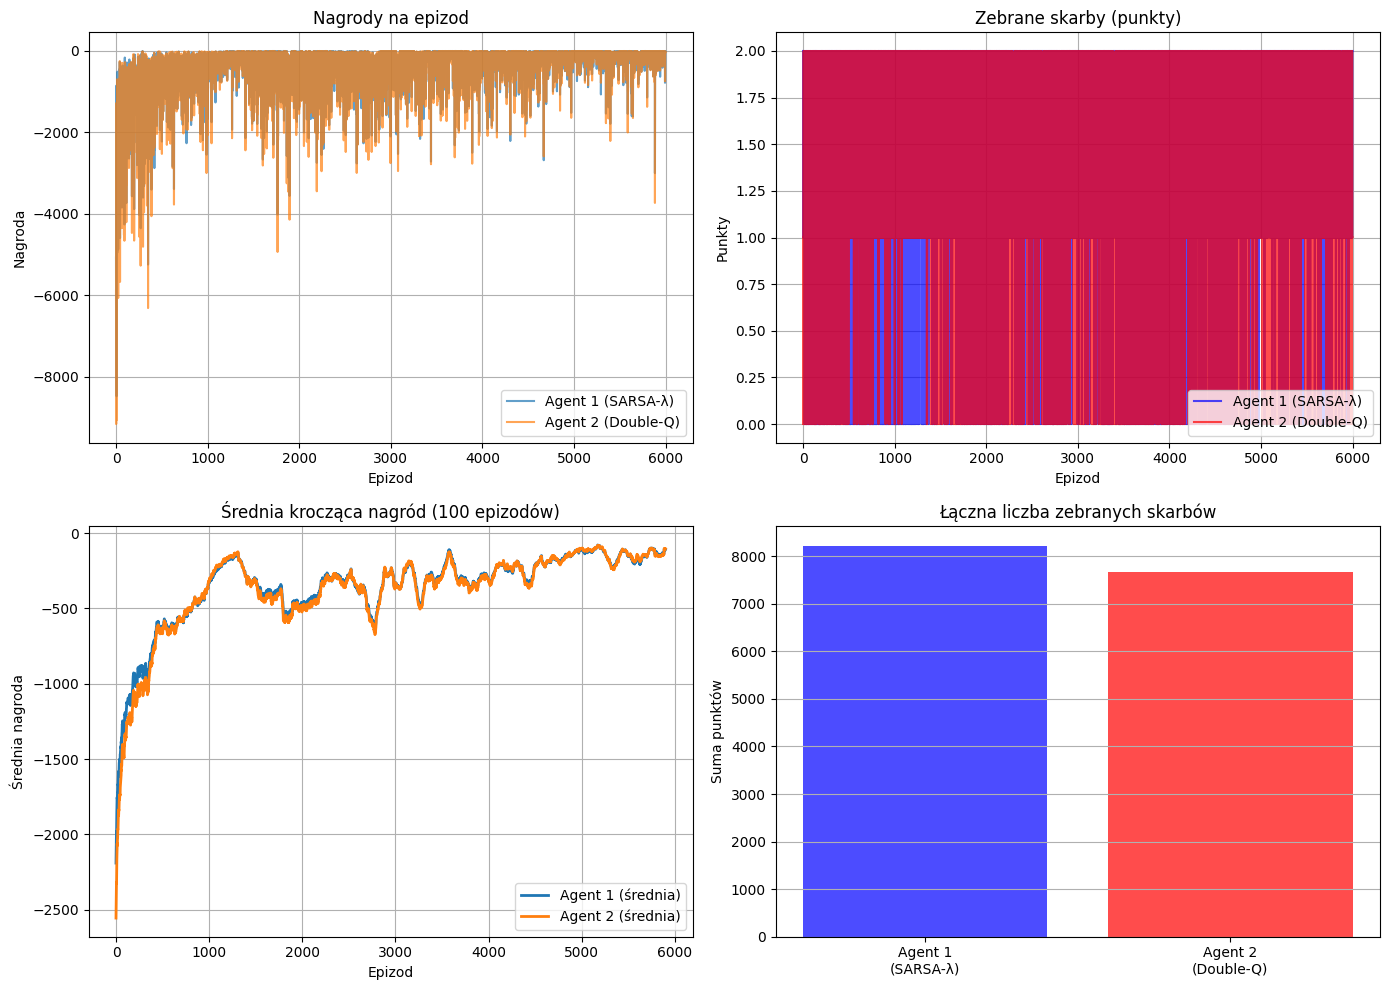


=== PODSUMOWANIE ===
Agent 1 (SARSA-λ):  Łącznie punktów: 8217, Średnia nagroda: -373.6
Agent 2 (Double-Q): Łącznie punktów: 7668, Średnia nagroda: -392.2

=== TESTOWANIE WYTRENOWANEJ POLITYKI ===

🎮 GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  3: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok  4: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok  5: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  6: A1=\/ DÓŁ, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok  9: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok 10: A1=\/ DÓŁ, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 11: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 12: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 15: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok 17: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok 18: A1=

In [ ]:
MAP1 = [
    "A....T....",
    "..#..#..#.",
    "T.......H.",
    "..#..T..#.",
    "....H....B"
]

MAP2 = [
    "A........T",
    "..#..#..#.",
    ".H..T...H.",
    ".#..#..#..",
    "T........B"
]

MAP3 = [
    "A....H...T",
    ".#.#....#.",
    ".H.#T..#H.",
    "..#...H.#.",
    "T...H....B"
]


In [ ]:
import importlib
import agents
importlib.reload(agents)
from agents import QLearningAgent, SARSAAgent, ExpectedSARSAAgent


Trening agentów (Q-Learning vs SARSA):
Epizod  100 | Agent1: R=-1237.0 P=1 | Agent2: R=-1419.0 P=1
Epizod  200 | Agent1: R=-397.0 P=0 | Agent2: R=-296.0 P=2
Epizod  300 | Agent1: R= -14.0 P=2 | Agent2: R= -21.0 P=1
Epizod  400 | Agent1: R= -72.0 P=2 | Agent2: R= -84.0 P=0
Epizod  500 | Agent1: R= -26.0 P=2 | Agent2: R= -91.0 P=1
Epizod  600 | Agent1: R= -31.0 P=2 | Agent2: R= -67.0 P=1
Epizod  700 | Agent1: R=-660.0 P=2 | Agent2: R=-788.0 P=0
Epizod  800 | Agent1: R=-333.0 P=2 | Agent2: R=-278.0 P=1
Epizod  900 | Agent1: R=-156.0 P=2 | Agent2: R=-194.0 P=1
Epizod 1000 | Agent1: R=-399.0 P=2 | Agent2: R=-560.0 P=0
Epizod 1100 | Agent1: R=  -6.0 P=2 | Agent2: R= -13.0 P=1
Epizod 1200 | Agent1: R= -19.0 P=1 | Agent2: R= -12.0 P=2
Epizod 1300 | Agent1: R= -57.0 P=2 | Agent2: R=-122.0 P=1
Epizod 1400 | Agent1: R=-287.0 P=1 | Agent2: R=-394.0 P=2
Epizod 1500 | Agent1: R= -12.0 P=2 | Agent2: R= -19.0 P=1
Epizod 1600 | Agent1: R=-362.0 P=1 | Agent2: R=-708.0 P=1
Epizod 1700 | Agent1: R=-358.0

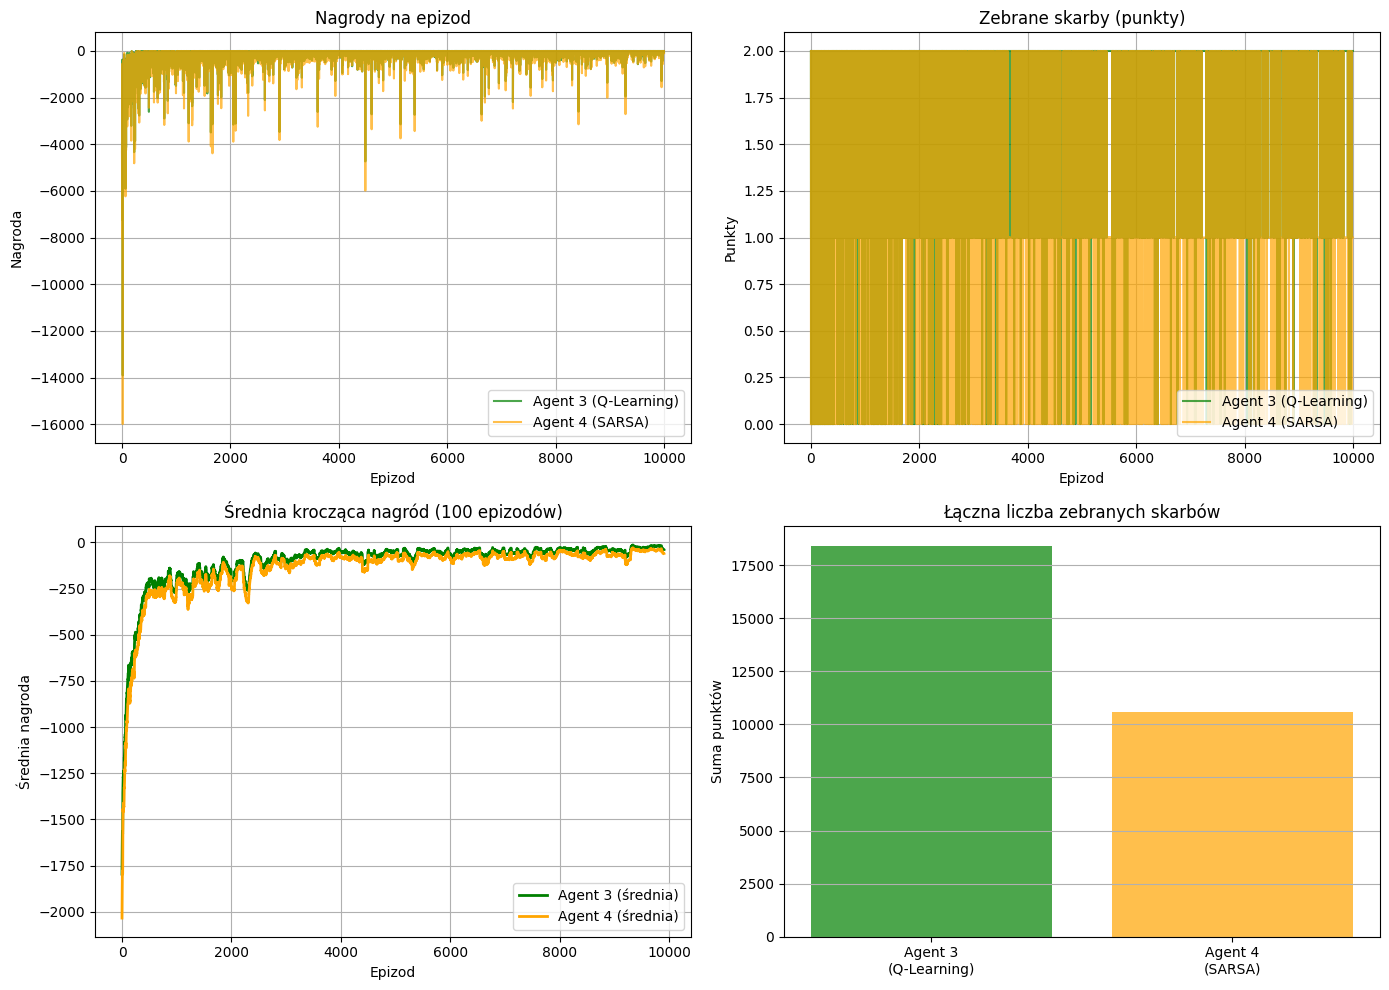

Agent 3 (Q-Learning): Łącznie punktów: 18405, Średnia nagroda: -116.1
Agent 4 (SARSA):      Łącznie punktów: 10564, Średnia nagroda: -151.9

=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs SARSA) ===

🎮 GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=\/ DÓŁ, A2=/\ GÓRA | R1=+1 R2=+1 T: A1 T: A2
Krok  5: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=\/ DÓŁ | R1=+4 R2=+4 [H]: A1 [H]: A2
Krok  9: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 10: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 11: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok 12: A1=>> PRAWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=>> PRAWO | R1=+1 R2=-1 T: A1
Krok 15: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok 17: A1=<<

In [73]:
env2 = MultiTreasureHunterMDP(MAP3)
state2 = env2.reset()

# Agent 3: SARSA
agent3 = SARSAAgent(
    alpha=0.1, epsilon=0.15, discount=0.9,
    get_legal_actions=lambda s: env2.get_possible_actions(s, agent_id='1')
)

# Agent 4: Q-Learning
agent4 = QLearningAgent(
    alpha=0.1, epsilon=0.15, discount=0.9,
    get_legal_actions=lambda s: env2.get_possible_actions(s, agent_id='2')
)

print("\nTrening agentów (Q-Learning vs SARSA):")
rewards3, rewards4, scores3, scores4 = play_and_train_multi(env2, agent3, agent4, episodes=10000)

print(f"\nAgent 3 (Q-Learning) zna {len(agent3._qvalues)} stanów")
print(f"Agent 4 (SARSA) zna {len(agent4._qvalues)} stanów")

# Wykresy porównawcze
plt.figure(figsize=(14, 10))

# Nagrody agentów
plt.subplot(2, 2, 1)
plt.plot(rewards3, label='Agent 3 (Q-Learning)', alpha=0.7, color='green')
plt.plot(rewards4, label='Agent 4 (SARSA)', alpha=0.7, color='orange')
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

# Punkty (zebrane skarby) agentów
plt.subplot(2, 2, 2)
plt.plot(scores3, label='Agent 3 (Q-Learning)', color='green', alpha=0.7)
plt.plot(scores4, label='Agent 4 (SARSA)', color='orange', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

# Średnie kroczące nagród (100 epizodów)
plt.subplot(2, 2, 3)
window = 100
if len(rewards3) >= window:
    avg_r3 = np.convolve(rewards3, np.ones(window)/window, mode='valid')
    avg_r4 = np.convolve(rewards4, np.ones(window)/window, mode='valid')
    plt.plot(avg_r3, label='Agent 3 (średnia)', linewidth=2, color='green')
    plt.plot(avg_r4, label='Agent 4 (średnia)', linewidth=2, color='orange')
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

# Porównanie całkowitych punktów
plt.subplot(2, 2, 4)
total_scores3 = sum(scores3)
total_scores4 = sum(scores4)
plt.bar(['Agent 3\n(Q-Learning)', 'Agent 4\n(SARSA)'], 
        [total_scores3, total_scores4], 
        color=['green', 'orange'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Agent 3 (Q-Learning): Łącznie punktów: {total_scores3}, Średnia nagroda: {np.mean(rewards3):.1f}")
print(f"Agent 4 (SARSA):      Łącznie punktów: {total_scores4}, Średnia nagroda: {np.mean(rewards4):.1f}")

print("\n=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs SARSA) ===")
test_policy(env2, agent3, agent4, episodes=1, delay=0.3)

In [77]:
# ROZWIAZANIE: Uzyj biblioteki dill zamiast pickle
# dill potrafi zapisac lambdy!

try:
    import dill
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
    import dill

import os

# Zapisz w tym samym folderze co notebook (bez tworzenia podfolderu)
# Zapisz agent3 (SARSA) uzywajac dill
with open('agentSARSA.pkl', 'wb') as f:
    dill.dump(agent3, f)
print("[OK] Agent 3 (SARSA) zapisany jako: agentSARSA.pkl")

# Zapisz agent4 (Q-Learning)
with open('agentQLearning.pkl', 'wb') as f:
    dill.dump(agent4, f)
print("[OK] Agent 4 (Q-Learning) zapisany jako: agentQLearning.pkl")

# Pokaz statystyki
print("\n=== Statystyki zapisanych agentow ===")
print(f"Agent 3 (SARSA):      {len(agent3._qvalues)} znanych stanow")
print(f"Agent 4 (Q-Learning): {len(agent4._qvalues)} znanych stanow")

print("\n[>] Pliki zapisane w folderze:")
print(f"    {os.path.abspath('.')}")
print("\n[>] Teraz mozesz uruchomic:")
print("    python test_game.py")

[OK] Agent 3 (SARSA) zapisany jako: agentSARSA.pkl
[OK] Agent 4 (Q-Learning) zapisany jako: agentQLearning.pkl

=== Statystyki zapisanych agentow ===
Agent 3 (SARSA):      86346 znanych stanow
Agent 4 (Q-Learning): 86346 znanych stanow

[>] Pliki zapisane w folderze:
    c:\Users\jasin\.Astudia\ucz_ze_wzmoc\treasurerEnv

[>] Teraz mozesz uruchomic:
    python test_game.py


### QLearning vs ExpectedSARSA:


Trening agentów (ExpectedSARSA vs Q-Learning):
Epizod  100 | Agent1: R=-957.0 P=1 | Agent2: R=-1253.0 P=1
Epizod  200 | Agent1: R=-127.0 P=2 | Agent2: R=-225.0 P=1
Epizod  300 | Agent1: R=-977.0 P=2 | Agent2: R=-984.0 P=1
Epizod  400 | Agent1: R= -42.0 P=2 | Agent2: R= -78.0 P=1
Epizod  500 | Agent1: R= -85.0 P=1 | Agent2: R=-107.0 P=2
Epizod  600 | Agent1: R=-252.0 P=1 | Agent2: R=-392.0 P=2
Epizod  700 | Agent1: R=-1084.0 P=2 | Agent2: R=-1039.0 P=1
Epizod  800 | Agent1: R=-475.0 P=2 | Agent2: R=-489.0 P=0
Epizod  900 | Agent1: R=-576.0 P=2 | Agent2: R=-436.0 P=1
Epizod 1000 | Agent1: R=-323.0 P=2 | Agent2: R=-370.0 P=0
Epizod 1100 | Agent1: R=-131.0 P=0 | Agent2: R=-119.0 P=2
Epizod 1200 | Agent1: R= -21.0 P=1 | Agent2: R= -14.0 P=2
Epizod 1300 | Agent1: R=-173.0 P=2 | Agent2: R=-124.0 P=1
Epizod 1400 | Agent1: R= -34.0 P=2 | Agent2: R= -99.0 P=1
Epizod 1500 | Agent1: R=-435.0 P=1 | Agent2: R=-509.0 P=2
Epizod 1600 | Agent1: R= -18.0 P=2 | Agent2: R= -54.0 P=1
Epizod 1700 | Agent1:

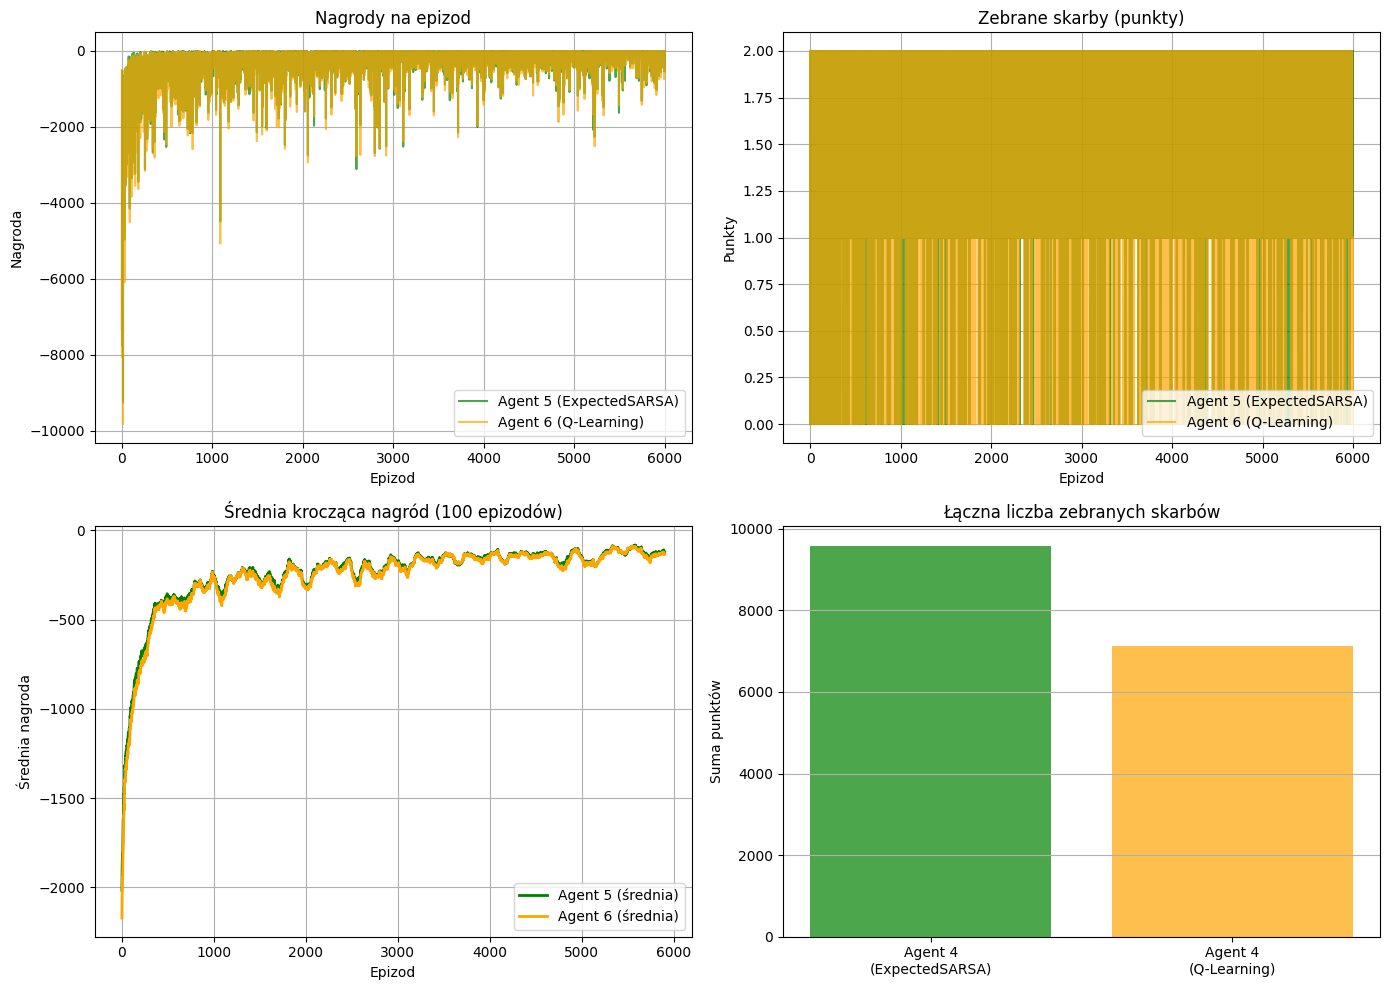

Agent 5 (ExpectedSarsa): Łącznie punktów: 9579, Średnia nagroda: -261.8
Agent 6 (Q-Learning):      Łącznie punktów: 7115, Średnia nagroda: -276.6

=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs ExpectedSARSA) ===

🎮 GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=\/ DÓŁ, A2=/\ GÓRA | R1=+1 R2=+1 T: A1 T: A2
Krok  5: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=\/ DÓŁ | R1=+4 R2=+4 [H]: A1 [H]: A2
Krok  9: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 10: A1=>> PRAWO, A2=>> PRAWO | R1=-1 R2=-1
Krok 11: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 12: A1=>> PRAWO, A2=>> PRAWO | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=<< LEWO | R1=+1 R2=-1 T: A1
Krok 15: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-

In [ ]:
import matplotlib.pyplot as plt
env3 = MultiTreasureHunterMDP(MAP3)
state3 = env3.reset()

agent5 = QLearningAgent(
    alpha=0.1, epsilon=0.15, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='1')
)

agent6 = ExpectedSARSAAgent(
    alpha=0.1, epsilon=0.15, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='2')
)

print("\nTrening agentów (Q-Learning vs ExpectedSARSA):")
rewards5, rewards6, scores5, scores6 = play_and_train_multi(env3, agent5, agent6, episodes=6000)

print(f"\nAgent 5 (Q-Learning) zna {len(agent5._qvalues)} stanów")
print(f"Agent 6 (ExpectedSARSA) zna {len(agent6._qvalues)} stanów")

# Wykresy porównawcze
plt.figure(figsize=(14, 10))

# Nagrody agentów
plt.subplot(2, 2, 1)
plt.plot(rewards5, label='Agent 5 (ExpectedSARSA)', alpha=0.7, color='green')
plt.plot(rewards6, label='Agent 6 (Q-Learning)', alpha=0.7, color='orange')
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(scores5, label='Agent 5 (QLearning)', color='green', alpha=0.7)
plt.plot(scores6, label='Agent 6 (ExpectedSARSA)', color='orange', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
window = 100
if len(rewards5) >= window:
    avg_r5 = np.convolve(rewards5, np.ones(window)/window, mode='valid')
    avg_r6 = np.convolve(rewards6, np.ones(window)/window, mode='valid')
    plt.plot(avg_r5, label='Agent 5 (średnia)', linewidth=2, color='green')
    plt.plot(avg_r6, label='Agent 6 (średnia)', linewidth=2, color='orange')
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

plt.subplot(2, 2, 4)
total_scores5 = sum(scores5)
total_scores6 = sum(scores6)
plt.bar(['Agent 5\n(QLearning)', 'Agent 6\n(ExpectedSARSA)'], 
        [total_scores5, total_scores6], 
        color=['green', 'orange'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Agent 5 (QLearning): Łącznie punktów: {total_scores5}, Średnia nagroda: {np.mean(rewards5):.1f}")
print(f"Agent 6 (ExpectedSarsa):      Łącznie punktów: {total_scores6}, Średnia nagroda: {np.mean(rewards6):.1f}")

print("\n=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs ExpectedSARSA) ===")
test_policy(env3, agent5, agent6, episodes=1, delay=0.3)

In [81]:
try:
    import dill
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
    import dill

import os

# Zapisz agent5 (SARSA) uzywajac dill
with open('agentExpectedSARSA.pkl', 'wb') as f:
    dill.dump(agent6, f)
print("[OK] Agent 5 (ExpectedSARSA) zapisany jako: agentExpectedSARSA.pkl")

# Zapisz agent6 (Q-Learning)
with open('agentQLearning2.pkl', 'wb') as f:
    dill.dump(agent5, f)
print("[OK] Agent 6 (Q-Learning) zapisany jako: agentQLearning2.pkl")

# Pokaz statystyki
print("\n=== Statystyki zapisanych agentow ===")
print(f"Agent 3 (ExpectedSARSA):      {len(agent5._qvalues)} znanych stanow")
print(f"Agent 4 (Q-Learning): {len(agent6._qvalues)} znanych stanow")

print("\n[>] Pliki zapisane w folderze:")
print(f"    {os.path.abspath('.')}")
print("\n[>] Teraz mozesz uruchomic:")
print("    python test_game.py")

[OK] Agent 5 (ExpectedSARSA) zapisany jako: agentExpectedSARSA.pkl
[OK] Agent 6 (Q-Learning) zapisany jako: agentQLearning2.pkl

=== Statystyki zapisanych agentow ===
Agent 3 (ExpectedSARSA):      100388 znanych stanow
Agent 4 (Q-Learning): 100388 znanych stanow

[>] Pliki zapisane w folderze:
    c:\Users\jasin\.Astudia\ucz_ze_wzmoc\treasurerEnv

[>] Teraz mozesz uruchomic:
    python test_game.py


### SARSALambda vs Double-Q-Learning:

Trening agentów:
Epizod  100 | Agent1: R=-288.0 P=2 | Agent2: R=-351.0 P=1
Epizod  200 | Agent1: R=-499.0 P=0 | Agent2: R=-657.0 P=2
Epizod  300 | Agent1: R=-1146.0 P=2 | Agent2: R=-1382.0 P=0
Epizod  400 | Agent1: R=-170.0 P=2 | Agent2: R=-293.0 P=1
Epizod  500 | Agent1: R=-192.0 P=1 | Agent2: R=-183.0 P=2
Epizod  600 | Agent1: R=-202.0 P=0 | Agent2: R=-217.0 P=2
Epizod  700 | Agent1: R=-151.0 P=1 | Agent2: R=-175.0 P=2
Epizod  800 | Agent1: R=-290.0 P=1 | Agent2: R=-254.0 P=2
Epizod  900 | Agent1: R=-732.0 P=1 | Agent2: R=-522.0 P=2
Epizod 1000 | Agent1: R=-141.0 P=0 | Agent2: R=-183.0 P=2
Epizod 1100 | Agent1: R=-158.0 P=2 | Agent2: R=-194.0 P=1
Epizod 1200 | Agent1: R=-228.0 P=2 | Agent2: R=-213.0 P=0
Epizod 1300 | Agent1: R= -17.0 P=1 | Agent2: R= -10.0 P=2
Epizod 1400 | Agent1: R=-877.0 P=1 | Agent2: R=-1071.0 P=2
Epizod 1500 | Agent1: R=-169.0 P=2 | Agent2: R=-178.0 P=1
Epizod 1600 | Agent1: R=-576.0 P=2 | Agent2: R=-646.0 P=0
Epizod 1700 | Agent1: R=-562.0 P=1 | Agent2: R=-678.

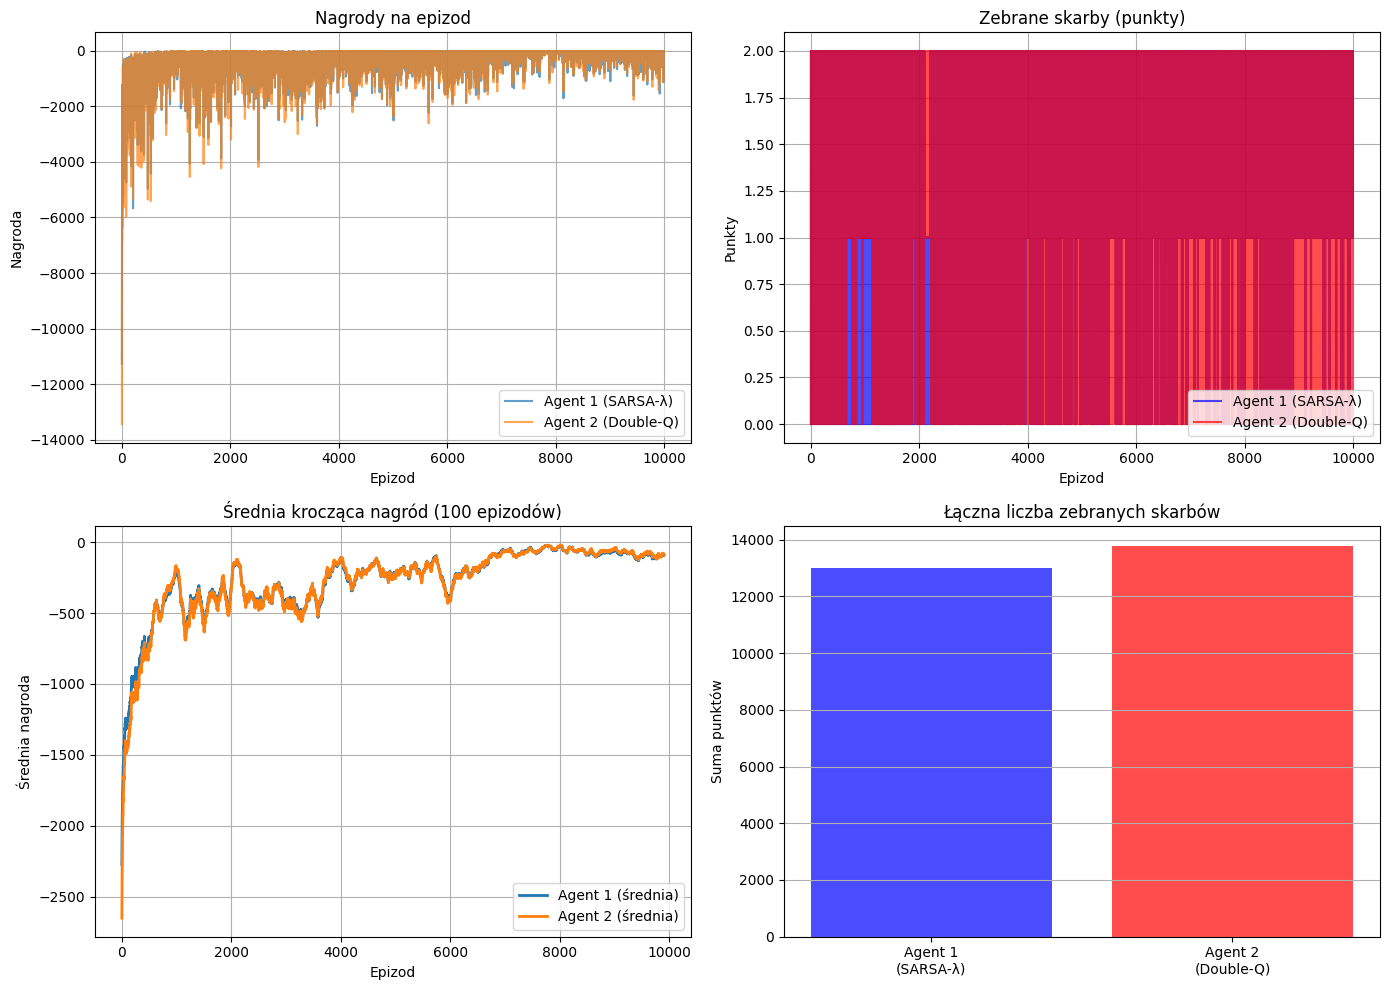


=== PODSUMOWANIE ===
Agent 1 (SARSA-λ):  Łącznie punktów: 12997, Średnia nagroda: -279.4
Agent 2 (Double-Q): Łącznie punktów: 13777, Średnia nagroda: -289.0

=== TESTOWANIE WYTRENOWANEJ POLITYKI ===

🎮 GRA TESTOWA 1
Krok  1: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=+1 T: A2
Krok  5: A1=<< LEWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=<< LEWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=<< LEWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=<< LEWO, A2=\/ DÓŁ | R1=-1 R2=+4 [H]: A2
Krok  9: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 10: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 11: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 12: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=<< LEWO | R1=+1 R2=-1 T: A1
Krok 15: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=+1 T: A2
Krok 16: A1=<< LEWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 17: A1=/\ GÓRA, A2=>>

In [87]:
env = MultiTreasureHunterMDP(MAP3)
state = env.reset()

agent1 = SARSALambdaAgent(
    alpha=0.1, epsilon=0.5, discount=0.99,
    get_legal_actions=lambda s: env.get_possible_actions(s, agent_id='1'),
    lambda_value=0.9
)
agent2 = DQLearningAgent(
    alpha=0.1, epsilon=0.5, discount=0.99,
    get_legal_actions=lambda s: env.get_possible_actions(s, agent_id='2')
)

print("Trening agentów:")
rewards1, rewards2, scores1, scores2 = play_and_train_multi(env, agent1, agent2, episodes=10000)

print(f"Agent 1 zna {len(agent1._qvalues)} stanów")
print(f"Agent 2 zna {len(agent2._qvaluesA) + len(agent2._qvaluesB)} stanów (z obu tabel)")

# Wykresy porównawcze dla obu agentów
plt.figure(figsize=(14, 10))

# Nagrody agentów
plt.subplot(2, 2, 1)
plt.plot(rewards1, label='Agent 1 (SARSA-λ)', alpha=0.7)
plt.plot(rewards2, label='Agent 2 (Double-Q)', alpha=0.7)
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

# Punkty (zebrane skarby) agentów
plt.subplot(2, 2, 2)
plt.plot(scores1, label='Agent 1 (SARSA-λ)', color='blue', alpha=0.7)
plt.plot(scores2, label='Agent 2 (Double-Q)', color='red', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

# Średnie kroczące nagród (100 epizodów)
plt.subplot(2, 2, 3)
window = 100
if len(rewards1) >= window:
    avg_r1 = np.convolve(rewards1, np.ones(window)/window, mode='valid')
    avg_r2 = np.convolve(rewards2, np.ones(window)/window, mode='valid')
    plt.plot(avg_r1, label='Agent 1 (średnia)', linewidth=2)
    plt.plot(avg_r2, label='Agent 2 (średnia)', linewidth=2)
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

# Porównanie całkowitych punktów
plt.subplot(2, 2, 4)
total_scores1 = sum(scores1)
total_scores2 = sum(scores2)
plt.bar(['Agent 1\n(SARSA-λ)', 'Agent 2\n(Double-Q)'], 
        [total_scores1, total_scores2], 
        color=['blue', 'red'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"\n=== PODSUMOWANIE ===")
print(f"Agent 1 (SARSA-λ):  Łącznie punktów: {total_scores1}, Średnia nagroda: {np.mean(rewards1):.1f}")
print(f"Agent 2 (Double-Q): Łącznie punktów: {total_scores2}, Średnia nagroda: {np.mean(rewards2):.1f}")

print("\n=== TESTOWANIE WYTRENOWANEJ POLITYKI ===")
test_policy(env, agent1, agent2, episodes=1)

In [88]:
try:
    import dill
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
    import dill

import os

with open('agentSARSALambda.pkl', 'wb') as f:
    dill.dump(agent1, f)
print("[OK] Agent 3 (SARSA Lambda) zapisany jako: agentSARSALambda.pkl")

with open('agentDQLearning.pkl', 'wb') as f:
    dill.dump(agent2, f)
print("[OK] Agent 4 (DQ-Learning) zapisany jako: agentDQLearning.pkl")

# Pokaz statystyki
print("\n=== Statystyki zapisanych agentow ===")
print(f"Agent 3 (SARSA Lambda):      {len(agent1._qvalues)} znanych stanow")
# print(f"Agent 4 (DQ-Learning): {len(agent2._qvalues)} znanych stanow")

print("\n[>] Pliki zapisane w folderze:")
print(f"    {os.path.abspath('.')}")
print("\n[>] Teraz mozesz uruchomic:")
print("    python test_game.py")

[OK] Agent 3 (SARSA Lambda) zapisany jako: agentSARSALambda.pkl
[OK] Agent 4 (DQ-Learning) zapisany jako: agentDQLearning.pkl

=== Statystyki zapisanych agentow ===
Agent 3 (SARSA Lambda):      153233 znanych stanow

[>] Pliki zapisane w folderze:
    c:\Users\jasin\.Astudia\ucz_ze_wzmoc\treasurerEnv

[>] Teraz mozesz uruchomic:
    python test_game.py
